In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Load dataset
wine = load_wine()

X = wine.data
y = wine.target

# Dataset information
print("Features:", wine.feature_names)
print("Target Classes:", wine.target_names)

# Create DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

# Display first few rows
df.head()

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target Classes: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    knn_accuracies.append(accuracy)

    print(f"K={k}: {accuracy:.4f}")

K=1: 0.7778
K=5: 0.7222
K=11: 0.7500
K=15: 0.7500
K=21: 0.7778


In [4]:
from sklearn.neighbors import RadiusNeighborsClassifier
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []
for radius in radius_values:
    model = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label='most_frequent'
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    rnn_accuracies.append(accuracy)
    print(f"Radius={radius}: {accuracy:.4f}")

Radius=350: 0.7500
Radius=400: 0.7222
Radius=450: 0.7222
Radius=500: 0.7222
Radius=550: 0.7222
Radius=600: 0.7222


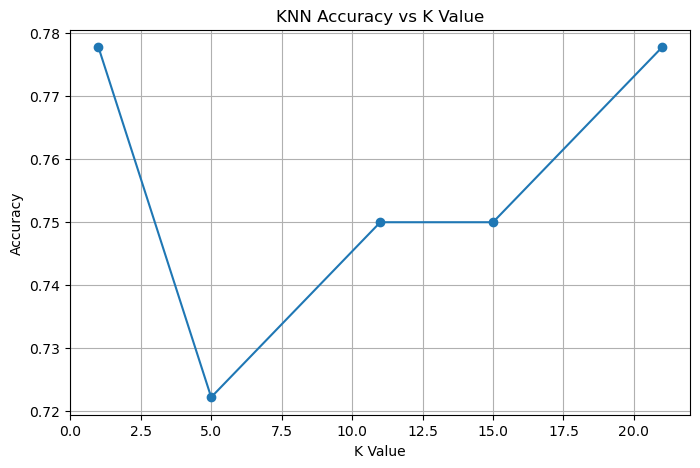

In [5]:
plt.figure(figsize=(8,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

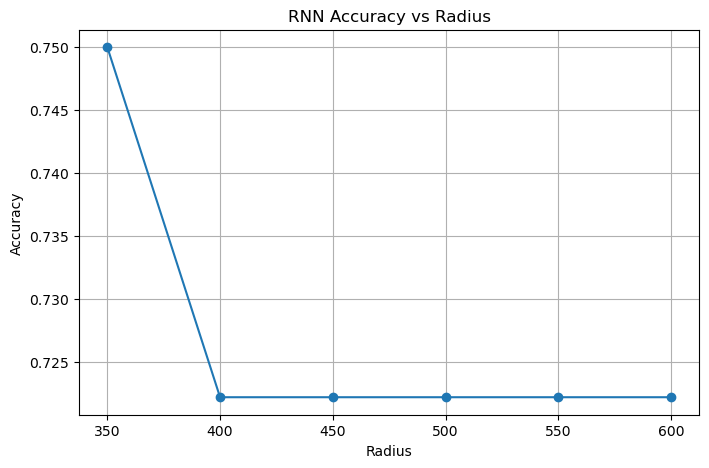

In [6]:
plt.figure(figsize=(8,5))
plt.plot(radius_values, rnn_accuracies, marker='o')
plt.title("RNN Accuracy vs Radius")
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()